# 🔵 K-Nearest Neighbors (KNN)

## Evaluation Metrics
- Accuracy
- Precision
- Recall
- F1 Score
- AUC-ROC

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print('Libraries imported successfully!')

Libraries imported successfully!


## 2. Load Processed Dataset

In [2]:
# Load the preprocessed dataset (already scaled by preprocess.py)
df = pd.read_csv('../../../data/processed/churn_processed.csv')

print(f'Dataset shape: {df.shape}')
print(f'Number of features: {df.shape[1] - 1}')
print(f'Number of samples: {df.shape[0]}')
df.head()

Dataset shape: (7032, 20)
Number of features: 19
Number of samples: 7032


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,-1.009430,-0.440327,1.035617,-0.652305,-1.280248,-3.056334,0.062666,-1.183614,-0.917837,1.242875,-1.026988,-0.924267,-1.112632,-1.121501,-0.826735,0.828939,0.399805,-1.161694,-0.994194,0
1,0.990658,-0.440327,-0.965608,-0.652305,0.064303,0.327189,-0.991564,-1.183614,1.408012,-1.028998,1.245441,-0.924267,-1.112632,-1.121501,0.373926,-1.206361,1.336636,-0.260878,-0.173740,0
2,0.990658,-0.440327,-0.965608,-0.652305,-1.239504,0.327189,-0.991564,-1.183614,1.408012,1.242875,-1.026988,-0.924267,-1.112632,-1.121501,-0.826735,0.828939,1.336636,-0.363923,-0.959649,1
3,0.990658,-0.440327,-0.965608,-0.652305,0.512486,-3.056334,0.062666,-1.183614,1.408012,-1.028998,1.245441,1.396963,-1.112632,-1.121501,0.373926,-1.206361,-1.473857,-0.747850,-0.195248,0
4,-1.009430,-0.440327,-0.965608,-0.652305,-1.239504,0.327189,-0.991564,0.172835,-0.917837,-1.028998,-1.026988,-0.924267,-1.112632,-1.121501,-0.826735,0.828939,0.399805,0.196178,-0.940457,1


In [3]:
# Check target distribution
print('Target Distribution:')
print(df['Churn'].value_counts())
print(f'\nChurn rate: {df["Churn"].mean() * 100:.2f}%')

Target Distribution:
Churn
0    5163
1    1869
Name: count, dtype: int64

Churn rate: 26.58%


## 3. Split Features & Target

In [4]:
# Separate features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

print(f'Features shape: {X.shape}')
print(f'Target shape:   {y.shape}')
print(f'\nFeature columns:\n{list(X.columns)}')

Features shape: (7032, 19)
Target shape:   (7032,)

Feature columns:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


## 4. Train-Test Split

> **Note:** The dataset was already **StandardScaler** normalized in `preprocess.py`, which is critical for KNN since it is distance-based. No additional scaling is needed here.

In [5]:
# Split data into training and testing sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Testing set:  {X_test.shape[0]} samples')
print(f'\nTraining churn rate: {y_train.mean() * 100:.2f}%')
print(f'Testing churn rate:  {y_test.mean() * 100:.2f}%')

Training set: 5625 samples
Testing set:  1407 samples

Training churn rate: 26.58%
Testing churn rate:  26.58%


## 5. Find the Optimal K (Elbow Method)

We test multiple values of K and compare their cross-validated F1 scores to find the best K before training the final model.

In [6]:
# Test K values from 1 to 30
k_range = range(1, 31)
k_scores_f1 = []
k_scores_acc = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    f1  = cross_val_score(knn, X_train, y_train, cv=5, scoring='f1').mean()
    acc = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy').mean()
    k_scores_f1.append(f1)
    k_scores_acc.append(acc)

best_k = k_range[np.argmax(k_scores_f1)]
print(f'Best K by F1 Score: {best_k}')
print(f'Best CV F1 Score:   {max(k_scores_f1):.4f}')

Best K by F1 Score: 29
Best CV F1 Score:   0.5615


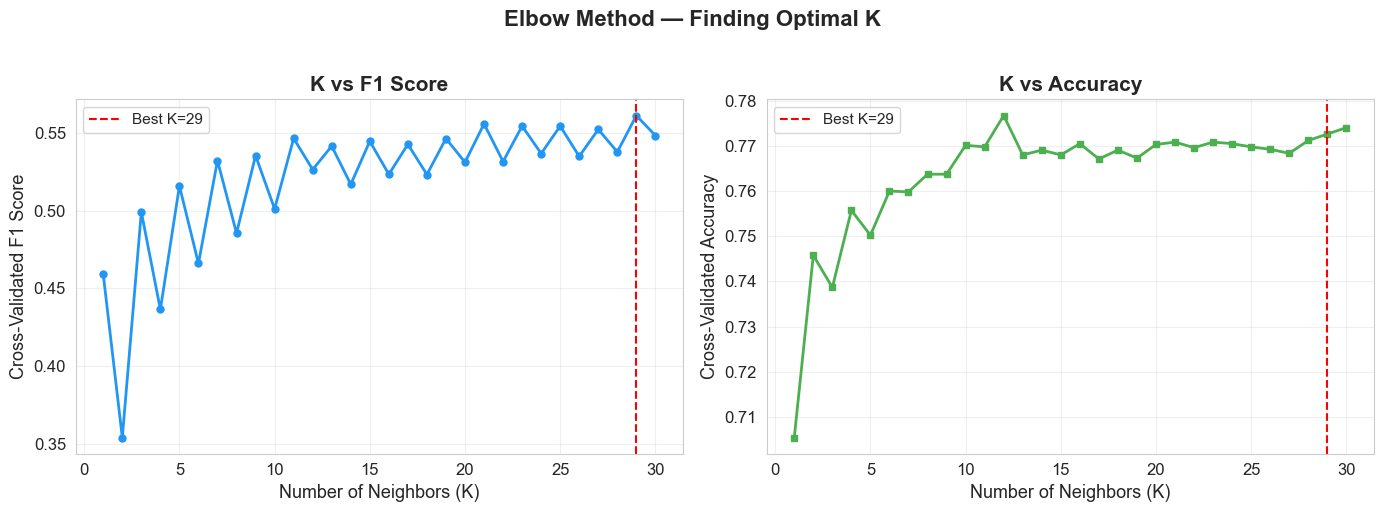

In [7]:
# Plot K vs F1 Score and Accuracy
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# F1 Score
axes[0].plot(k_range, k_scores_f1, marker='o', color='#2196F3', linewidth=2, markersize=5)
axes[0].axvline(x=best_k, color='red', linestyle='--', linewidth=1.5, label=f'Best K={best_k}')
axes[0].set_xlabel('Number of Neighbors (K)', fontsize=13)
axes[0].set_ylabel('Cross-Validated F1 Score', fontsize=13)
axes[0].set_title('K vs F1 Score', fontsize=15, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(k_range, k_scores_acc, marker='s', color='#4CAF50', linewidth=2, markersize=5)
axes[1].axvline(x=best_k, color='red', linestyle='--', linewidth=1.5, label=f'Best K={best_k}')
axes[1].set_xlabel('Number of Neighbors (K)', fontsize=13)
axes[1].set_ylabel('Cross-Validated Accuracy', fontsize=13)
axes[1].set_title('K vs Accuracy', fontsize=15, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Elbow Method — Finding Optimal K', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 6. Train KNN (Default K=5 as Baseline)

In [8]:
# Train with default K=5 as a baseline
knn_default = KNeighborsClassifier(n_neighbors=5)
knn_default.fit(X_train, y_train)

y_pred_default = knn_default.predict(X_test)

print('=== Default KNN (K=5) Results ===')
print(f'Accuracy:  {accuracy_score(y_test, y_pred_default):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_default):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_default):.4f}')
print(f'F1 Score:  {f1_score(y_test, y_pred_default):.4f}')

=== Default KNN (K=5) Results ===
Accuracy:  0.7491
Precision: 0.5279
Recall:    0.5321
F1 Score:  0.5300


## 7. Hyperparameter Tuning (GridSearchCV)

We tune not just K, but also the **distance metric** and **weighting scheme** for a more thorough search.

In [9]:
# Define parameter grid
param_grid = {
    'n_neighbors': list(range(1, 21)),   # K from 1 to 20
    'weights': ['uniform', 'distance'],  # uniform or distance-weighted
    'metric': ['euclidean', 'manhattan'] # distance metrics
}

knn = KNeighborsClassifier()

grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

print('Starting GridSearchCV...')
grid_search.fit(X_train, y_train)

print(f'\nBest Parameters: {grid_search.best_params_}')
print(f'Best CV F1 Score: {grid_search.best_score_:.4f}')

Starting GridSearchCV...
Fitting 5 folds for each of 80 candidates, totalling 400 fits

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 19, 'weights': 'uniform'}
Best CV F1 Score: 0.5752


## 8. Evaluate Best Model

In [10]:
# Get the best model
best_knn = grid_search.best_estimator_

# Predictions
y_pred       = best_knn.predict(X_test)
y_pred_proba = best_knn.predict_proba(X_test)[:, 1]

# === Core Metrics ===
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_pred_proba)

print('=' * 45)
print('    TUNED KNN — EVALUATION RESULTS')
print('=' * 45)
print(f'  Accuracy:  {accuracy:.4f}  ({accuracy * 100:.2f}%)')
print(f'  Precision: {precision:.4f}  ({precision * 100:.2f}%)')
print(f'  Recall:    {recall:.4f}  ({recall * 100:.2f}%)')
print(f'  F1 Score:  {f1:.4f}  ({f1 * 100:.2f}%)')
print(f'  AUC-ROC:   {auc_score:.4f}  ({auc_score * 100:.2f}%)')
print('=' * 45)

    TUNED KNN — EVALUATION RESULTS
  Accuracy:  0.7719  (77.19%)
  Precision: 0.5746  (57.46%)
  Recall:    0.5455  (54.55%)
  F1 Score:  0.5597  (55.97%)
  AUC-ROC:   0.8109  (81.09%)


In [11]:
# Detailed classification report
print('\nDetailed Classification Report:\n')
print(classification_report(y_test, y_pred, target_names=['Not Churn (0)', 'Churn (1)']))


Detailed Classification Report:

               precision    recall  f1-score   support

Not Churn (0)       0.84      0.85      0.85      1033
    Churn (1)       0.57      0.55      0.56       374

     accuracy                           0.77      1407
    macro avg       0.71      0.70      0.70      1407
 weighted avg       0.77      0.77      0.77      1407



## 9. Visualizations

### 9.1 Confusion Matrix

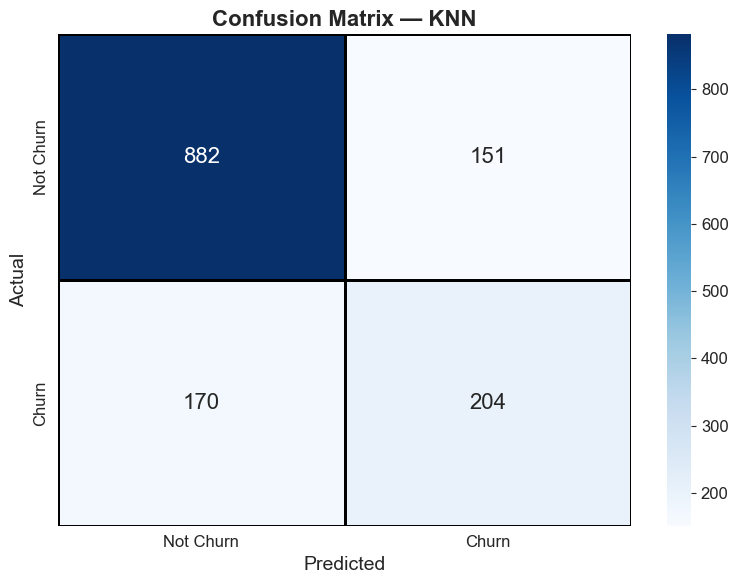

In [12]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Not Churn', 'Churn'],
    yticklabels=['Not Churn', 'Churn'],
    linewidths=1, linecolor='black',
    annot_kws={'size': 16}
)
ax.set_xlabel('Predicted', fontsize=14)
ax.set_ylabel('Actual', fontsize=14)
ax.set_title('Confusion Matrix — KNN', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### 9.2 ROC Curve

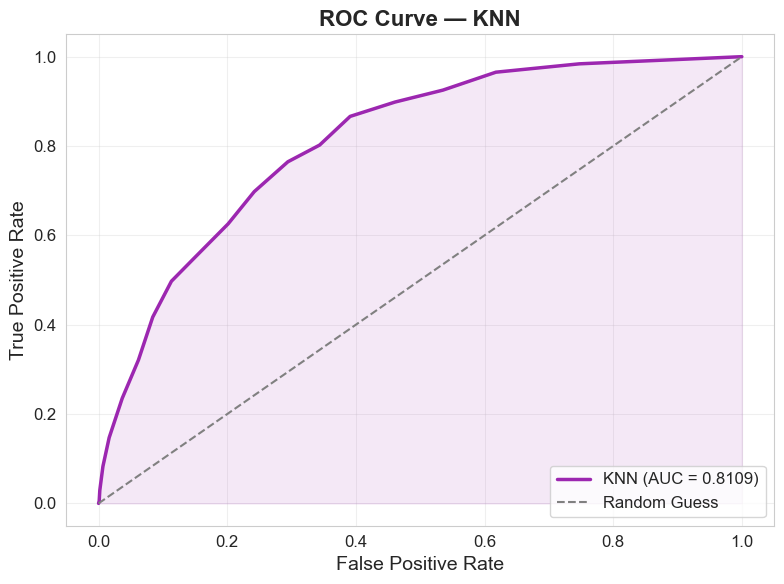

In [13]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='#9C27B0', lw=2.5, label=f'KNN (AUC = {auc_score:.4f})')
ax.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='Random Guess')
ax.fill_between(fpr, tpr, alpha=0.1, color='#9C27B0')
ax.set_xlabel('False Positive Rate', fontsize=14)
ax.set_ylabel('True Positive Rate', fontsize=14)
ax.set_title('ROC Curve — KNN', fontsize=16, fontweight='bold')
ax.legend(loc='lower right', fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 9.3 Metrics Comparison (Default K=5 vs Tuned KNN)

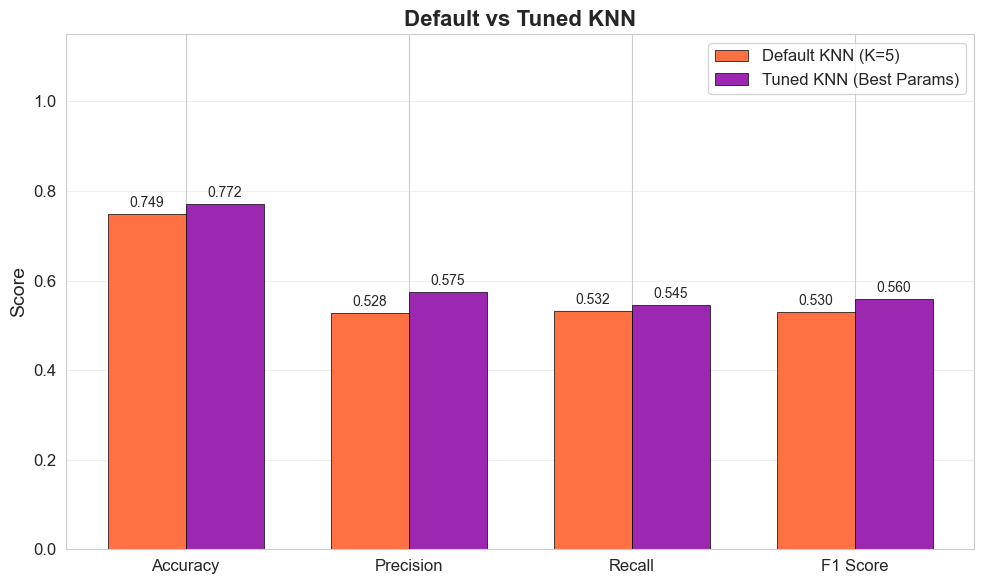

In [14]:
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

default_scores = [
    accuracy_score(y_test, y_pred_default),
    precision_score(y_test, y_pred_default),
    recall_score(y_test, y_pred_default),
    f1_score(y_test, y_pred_default)
]

tuned_scores = [accuracy, precision, recall, f1]

x = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, default_scores, width, label='Default KNN (K=5)', color='#FF7043', edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x + width/2, tuned_scores,   width, label=f'Tuned KNN (Best Params)', color='#9C27B0', edgecolor='black', linewidth=0.5)

for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 5), textcoords='offset points', ha='center', fontsize=10)

for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 5), textcoords='offset points', ha='center', fontsize=10)

ax.set_ylabel('Score', fontsize=14)
ax.set_title('Default vs Tuned KNN', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names, fontsize=12)
ax.legend(fontsize=12)
ax.set_ylim(0, 1.15)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Summary

In [15]:
summary = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC-ROC'],
    'Default KNN (K=5)': [
        accuracy_score(y_test, y_pred_default),
        precision_score(y_test, y_pred_default),
        recall_score(y_test, y_pred_default),
        f1_score(y_test, y_pred_default),
        roc_auc_score(y_test, knn_default.predict_proba(X_test)[:, 1])
    ],
    'Tuned KNN': [accuracy, precision, recall, f1, auc_score]
})

summary['Default KNN (K=5)'] = summary['Default KNN (K=5)'].round(4)
summary['Tuned KNN']         = summary['Tuned KNN'].round(4)
summary['Improvement']       = (summary['Tuned KNN'] - summary['Default KNN (K=5)']).round(4)

print('\n' + '=' * 60)
print('           KNN — FINAL SUMMARY')
print('=' * 60)
print(summary.to_string(index=False))
print('=' * 60)
print(f'\nBest hyperparameters: {grid_search.best_params_}')


           KNN — FINAL SUMMARY
   Metric  Default KNN (K=5)  Tuned KNN  Improvement
 Accuracy             0.7491     0.7719       0.0228
Precision             0.5279     0.5746       0.0467
   Recall             0.5321     0.5455       0.0134
 F1 Score             0.5300     0.5597       0.0297
  AUC-ROC             0.7711     0.8109       0.0398

Best hyperparameters: {'metric': 'manhattan', 'n_neighbors': 19, 'weights': 'uniform'}
